In [ ]:
from kan import KAN, LBFGS, MLP
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from tqdm import tqdm

device = torch.device('cpu')
print(device)

cpu


In [19]:
def sol_fun(x, dim):
    # half = x.shape[1] // 2
    # m = x[:, :half]
    # v = x[:, half:2*half]
    # return torch.sum(0.5 * m * (v ** 2), dim=1, keepdim=True)
    # return torch.exp(torch.sin(x[:, [0]]**2+x[:, [1]]**2) + torch.sin(x[:, [2]]**2+x[:, [3]]**2))
    return torch.exp(1/dim * torch.sum(torch.sin(torch.pi * x / 2) ** 2, dim=1, keepdim=True))

In [4]:
ranges = [-1, 1]
n_train = 1000
n_test = 200
steps = 100
grids = [3, 5, 10, 20, 50]
k=3
lr=0.1

In [16]:
def generate_dataset(dim, n_train=None, n_test=None):
    if n_train is None:
        n_train = globals().get('n_train', 1000)
    if n_test is None:
        n_test = globals().get('n_test', 200)
    x_train = torch.rand((n_train, dim), device=device) * (ranges[1] - ranges[0]) + ranges[0]
    y_train = sol_fun(x_train, dim)
    x_test = torch.rand((n_test, dim), device=device) * (ranges[1] - ranges[0]) + ranges[0]
    y_test = sol_fun(x_test, dim)
    dataset = {
        'train_input': x_train,
        'train_label': y_train,
        'test_input': x_test,
        'test_label': y_test
    }
    return dataset

In [10]:
def train_kan(width, dataset, static=True):
    
    rmses = []
    r2s = []
    preds = []
    if not static:
        run_steps = steps // len(grids)
    else:
        run_steps = steps

    for grid in grids:
        if grid == grids[0]:
            model = KAN(width=width, grid=grid, k=3, seed=1, device=device)
            model = model.speed()
        else:
            model.save_act = True
            model.get_act(dataset['train_input'])
            model = model.refine(grid)
            model = model.speed()
        criterion = torch.nn.MSELoss()
        num_params = sum(1 for _ in model.parameters())

        optimizer = LBFGS(
                model.parameters(), 
                lr=lr, 
                history_size=10, 
                line_search_fn="strong_wolfe",
                tolerance_grad=1e-32, 
                tolerance_change=1e-32, 
                tolerance_ys=1e-32
            )
        pbar = tqdm(range(run_steps), desc='description', ncols=100)

        for _ in pbar:
            def closure():
                optimizer.zero_grad()
                loss = criterion(model(dataset['train_input']), dataset['train_label'])
                loss.backward()
                return loss

            if _ % (steps//10)== 0 and _ < steps // 2:
                model.update_grid_from_samples(dataset['train_input'])

            optimizer.step(closure)
            with torch.no_grad():
                test_pred = model(dataset['test_input'])
                mse = criterion(test_pred, dataset['test_label'])
                rmse = torch.sqrt(mse).item()
                r2 = r2_score(dataset['test_label'].cpu().numpy(), test_pred.cpu().numpy())

            pbar.set_description("rmse: %.2e | r2: %.2e " % (rmse, r2))

            rmses.append(rmse)
            r2s.append(r2)
            preds.append(test_pred)
        if static:
            break
    
            
    results = {
        "rmses": rmses,
        "r2s": r2s,
        "preds": preds,
        "param_counts": num_params
    }
    return results

In [8]:
def train_mlp(width, dataset):
    
    def r2():
        with torch.no_grad():
            pred = mlp_model(dataset['test_input'].to(mlp_model.device))
        target = dataset['test_label'].to(mlp_model.device)
        ss_res = torch.sum((target - pred) ** 2)
        ss_tot = torch.sum((target - torch.mean(target)) ** 2)
        return 1 - (ss_res / ss_tot)
    
    mlp_model = MLP.MLP(width=width, act='silu', device='cpu')
    mlp_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
    results = mlp_model.fit(dataset, opt="LBFGS", steps=100, lr=0.1, metrics=[r2])
    results['param_counts'] = mlp_params
    return results

In [20]:
static_kan_results = {}
dyn_kan_results = {}
mlp_results = {}
for d in [100, 50, 20, 10, 5]:
    dataset = generate_dataset(dim=d)
    static_kan_results[d] = train_kan(width=[d, 1, 1], dataset=dataset, static=True)
    kan_param = static_kan_results[d]['param_counts']
    dyn_kan_results[d] = train_kan(width=[d, 1, 1], dataset=dataset, static=False)
    mlp_hidden_width = (kan_param - 1) // 4
    mlp_results[d] = train_mlp(width=[d, mlp_hidden_width, 1], dataset=dataset)
    mlp_param = mlp_results[d]['param_counts']
print(f"number of params in KAN (static): {kan_param}, KAN (dynamic): {dyn_kan_results[d]['param_counts']}, MLP: {mlp_param}")

checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                          | 0/100 [00:00<?, ?it/s]

rmse: 3.23e-03 | r2: 9.97e-01 : 100%|█████████████████████████████| 100/100 [00:48<00:00,  2.08it/s]


checkpoint directory created: ./model
saving model version 0.0


rmse: 7.07e-03 | r2: 9.84e-01 : 100%|███████████████████████████████| 20/20 [00:10<00:00,  1.88it/s]
rmse: 9.70e-04 | r2: 1.00e+00 : 100%|███████████████████████████████| 20/20 [00:11<00:00,  1.77it/s]
rmse: 5.68e-04 | r2: 1.00e+00 : 100%|███████████████████████████████| 20/20 [00:18<00:00,  1.08it/s]
rmse: 5.72e-04 | r2: 1.00e+00 : 100%|███████████████████████████████| 20/20 [00:19<00:00,  1.01it/s]
rmse: 5.71e-04 | r2: 1.00e+00 : 100%|███████████████████████████████| 20/20 [00:07<00:00,  2.85it/s]
| train_loss: 2.56e-02 | test_loss: 1.37e-01 | reg: 1.74e+02 | : 100%|█| 100/100 [00:06<00:00, 15.10


...

checkpoint directory created: ./model
saving model version 0.0


rmse: 9.08e-03 | r2: 9.99e-01 : 100%|█████████████████████████████| 100/100 [00:13<00:00,  7.27it/s]


checkpoint directory created: ./model
saving model version 0.0


rmse: 9.14e-03 | r2: 9.99e-01 : 100%|███████████████████████████████| 20/20 [00:05<00:00,  3.45it/s]
rmse: 9.18e-04 | r2: 1.00e+00 : 100%|███████████████████████████████| 20/20 [00:05<00:00,  3.58it/s]
rmse: 5.59e-05 | r2: 1.00e+00 : 100%|███████████████████████████████| 20/20 [00:04<00:00,  4.24it/s]
rmse: 7.35e-06 | r2: 1.00e+00 : 100%|███████████████████████████████| 20/20 [00:04<00:00,  4.00it/s]
rmse: 3.93e-06 | r2: 1.00e+00 : 100%|███████████████████████████████| 20/20 [00:02<00:00,  8.12it/s]
| train_loss: 1.21e-01 | test_loss: 1.28e-01 | reg: 3.88e+01 | : 100%|█| 100/100 [00:04<00:00, 20.49

number of params in KAN (static): 22, KAN (dynamic): 22, MLP: 36


Static KAN d=100 Final RMSE: 3.23e-03
Static KAN d=50 Final RMSE: 3.29e-03
Static KAN d=20 Final RMSE: 4.58e-03
Static KAN d=10 Final RMSE: 6.07e-03
Static KAN d=5 Final RMSE: 9.08e-03
MLP d=100 Final RMSE: 1.37e-01
MLP d=50 Final RMSE: 9.92e-02
MLP d=20 Final RMSE: 1.33e-01
MLP d=10 Final RMSE: 1.49e-01
MLP d=5 Final RMSE: 1.28e-01
Dynamic KAN d=100 Final RMSE: 5.71e-04
Dynamic KAN d=50 Final RMSE: 6.10e-04
Dynamic KAN d=20 Final RMSE: 1.88e-05
Dynamic KAN d=10 Final RMSE: 3.47e-06
Dynamic KAN d=5 Final RMSE: 3.93e-06


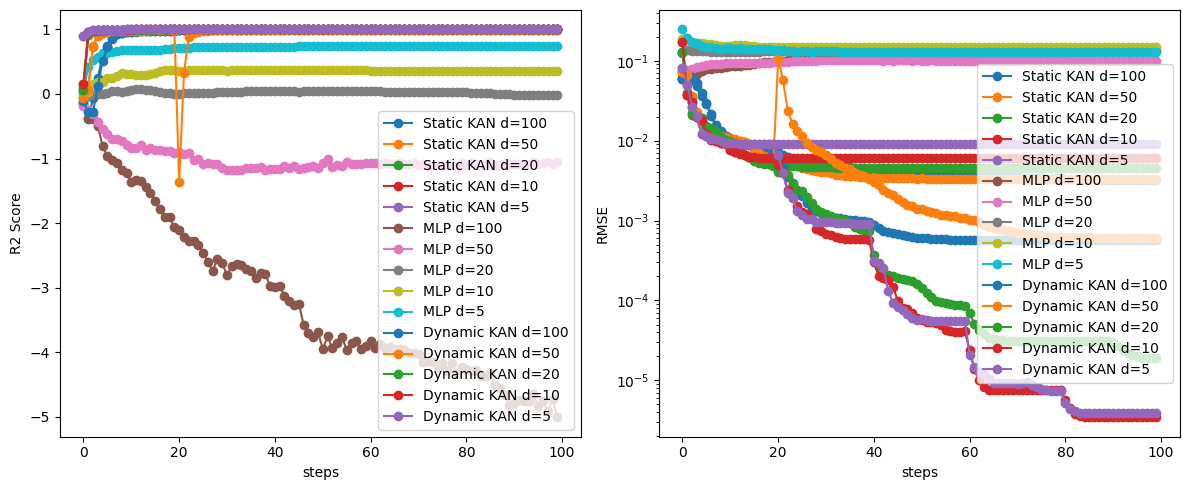

In [26]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for d, kan_result in static_kan_results.items():      
    label = f'Static KAN d={d}' 
    ax1.plot(kan_result['r2s'], marker='o', label=label)      
    ax2.plot(kan_result['rmses'], marker='o', label=label)      
    print(f"{label} Final RMSE: {kan_result['rmses'][-1]:.2e}")

for d, mlp_result in mlp_results.items():
    label = f'MLP d={d}'
    ax1.plot(mlp_result['r2'], marker='o', label=label)
    ax2.plot(mlp_result['test_loss'], marker='o', label=label)
    print(f"{label} Final RMSE: {mlp_result['test_loss'][-1]:.2e}")

for d, kan_result in dyn_kan_results.items():
    label = f'Dynamic KAN d={d}'
    ax1.plot(kan_result['r2s'], marker='o', label=label)
    ax2.plot(kan_result['rmses'], marker='o', label=label)
    print(f"{label} Final RMSE: {kan_result['rmses'][-1]:.2e}")

ax1.set_xlabel('steps')
ax1.set_ylabel('R2 Score')
ax1.legend()

ax2.set_yscale('log')
ax2.set_xlabel('steps')
ax2.set_ylabel('RMSE')
ax2.legend()

plt.tight_layout()
plt.show()

In [23]:
torch.save(static_kan_results, 'static_kan_results.pt')
torch.save(dyn_kan_results, 'dynamic_kan_results.pt')
torch.save(mlp_results, 'mlp_results.pt')

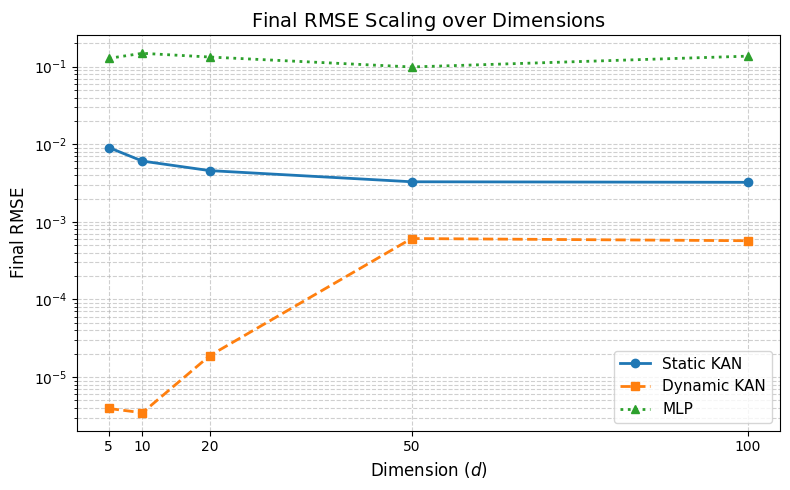

In [ ]:
# 1. Extract and sort the dimensions to ensure the lines plot from left to right
dimensions = sorted(static_kan_results.keys())

# 2. Collect the final RMSE (the last entry in the list) for each dimension
static_kan_final_rmse = [static_kan_results[d]['rmses'][-1] for d in dimensions]
dyn_kan_final_rmse = [dyn_kan_results[d]['rmses'][-1] for d in dimensions]
mlp_final_rmse = [mlp_results[d]['test_loss'][-1] for d in dimensions]

# 3. Create the plot
plt.figure(figsize=(8, 5))

plt.plot(dimensions, static_kan_final_rmse, marker='o', linestyle='-', linewidth=2, label='Static KAN')
plt.plot(dimensions, dyn_kan_final_rmse, marker='s', linestyle='--', linewidth=2, label='Dynamic KAN')
plt.plot(dimensions, mlp_final_rmse, marker='^', linestyle=':', linewidth=2, label='MLP')

# 4. Labeling and formatting
plt.xlabel('Dimension ($d$)', fontsize=12)
plt.ylabel('Final $\\text{RMSE}$', fontsize=12)
plt.title('Final $\\text{RMSE}$ Scaling over Dimensions', fontsize=14)

# Use logarithmic scales to better visualize scaling laws/orders of magnitude
plt.yscale('log')

# Force the x-axis to show your exact tested dimensions clearly
plt.xticks(dimensions, labels=[str(d) for d in dimensions])

plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

# 5. Display the plot
plt.show()

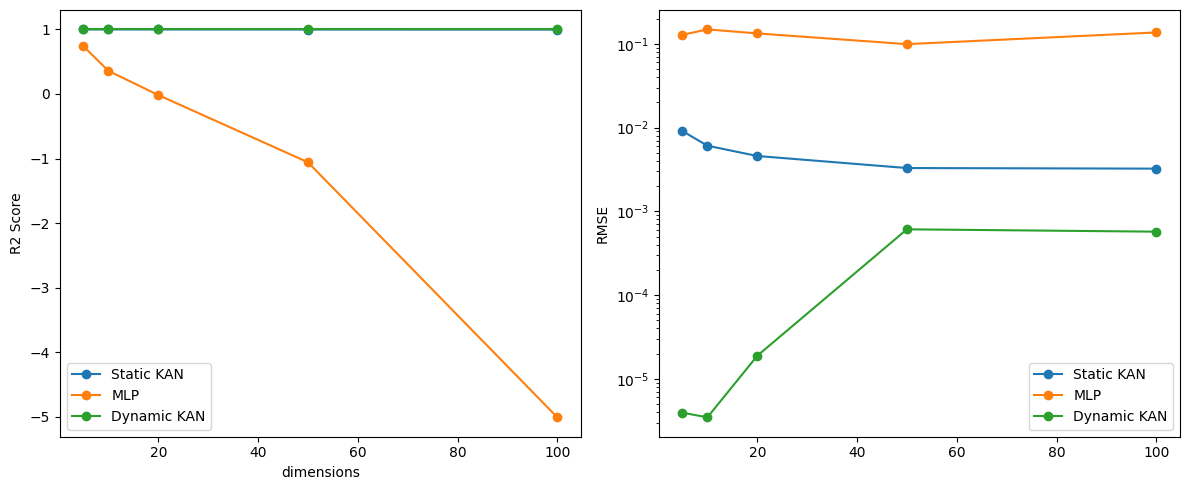

In [30]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


ax1.plot(dimensions, [static_kan_results[d]['r2s'][-1] for d in dimensions], marker='o', label='Static KAN')      
ax2.plot(dimensions, [static_kan_results[d]['rmses'][-1] for d in dimensions], marker='o', label='Static KAN')

ax1.plot(dimensions, [mlp_results[d]['r2'][-1] for d in dimensions], marker='o', label='MLP')
ax2.plot(dimensions, [mlp_results[d]['test_loss'][-1] for d in dimensions], marker='o', label='MLP')


ax1.plot(dimensions, [kan_result['r2s'][-1] for d in dimensions], marker='o', label='Dynamic KAN')
ax2.plot(dimensions, [dyn_kan_results[d]['rmses'][-1] for d in dimensions], marker='o', label='Dynamic KAN')

ax1.set_xlabel('dimensions')
ax1.set_ylabel('R2 Score')
ax1.legend()

ax2.set_yscale('log')
ax2.set_ylabel('RMSE')
ax2.legend()

plt.tight_layout()
plt.show()